# Corrected Contradiction Evaluation for MITR

This notebook fixes a bug in the original `create_contradiction_pairs()` function
and re-runs the contradiction rate evaluation to see how results change.

## The bug

The original code builds negated text as `"question [SEP] negated_question"`,
dropping the passage entirely. The forward input gets full passage context,
but the negated input does not. This means the reported contradiction rates
were not measuring logical consistency.

## What this notebook does

1. Fixes the negation code to preserve the passage
2. Re-trains Baseline and MITR-InfoNCE on DistilBERT / BoolQ (5 epochs, A100)
3. Compares old (buggy) vs new (fixed) contradiction rates

We run only Baseline + InfoNCE (the best strategy from the original results)
to focus on the effect of the contradiction fix.


In [1]:
# Run once - installs / upgrades required packages
!pip install -q --upgrade "transformers>=4.36" datasets accelerate matplotlib seaborn tqdm
print("Done.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 146.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.3 MB/s eta 0:00:00
Done.


In [2]:
import os, json, random, warnings
from dataclasses import dataclass
from typing import Dict, List, Optional
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    DistilBertModel,
    DistilBertTokenizerFast,
    get_cosine_schedule_with_warmup,
)
from datasets import load_dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")


PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
@dataclass
class Config:
    # ── Model ─────────────────────────────────────────────────
    model_name: str  = "distilbert-base-uncased"
    num_labels: int  = 2          # 0 = False/No,  1 = True/Yes

    # ── Training ──────────────────────────────────────────────
    batch_size: int       = 64    # safe for A100 40GB; raise to 128 for 80GB
    eval_batch_size: int  = 128
    learning_rate: float  = 2e-5
    weight_decay: float   = 0.01
    num_epochs: int       = 5
    warmup_ratio: float   = 0.06
    max_grad_norm: float  = 1.0
    grad_accum_steps: int = 1     # effective batch = batch_size * grad_accum_steps

    # ── MITR ──────────────────────────────────────────────────
    mi_lambda: float     = 0.01   # MI penalty weight
    mi_warmup_steps: int = 200    # ramp lambda 0 → mi_lambda over this many steps
    club_hidden: int     = 384    # hidden dim for CLUB / InfoNCE / Cosine networks
    mi_strategy: str     = "club" # "club", "infonce", "cosine", or "cka"

    # ── Data ──────────────────────────────────────────────────
    dataset: str         = "boolq"   # "boolq" or "ruletaker"
    max_length: int      = 256
    num_train: int       = 8000      # -1 = full dataset
    num_eval: int        = 1500
    num_contra: int      = 500       # contradiction pairs from val set
    num_workers: int     = 4

    # ── A100 ──────────────────────────────────────────────────
    use_bf16: bool       = True      # BF16 is optimal on A100
    compile_model: bool  = True      # torch.compile() kernel fusion
    seed: int            = 42

    # ── Output ────────────────────────────────────────────────
    output_dir: str      = "experiment_results"

CFG = Config()
print(CFG)

Config(model_name='distilbert-base-uncased', num_labels=2, batch_size=64, eval_batch_size=128, learning_rate=2e-05, weight_decay=0.01, num_epochs=5, warmup_ratio=0.06, max_grad_norm=1.0, grad_accum_steps=1, mi_lambda=0.01, mi_warmup_steps=200, club_hidden=384, mi_strategy='club', dataset='boolq', max_length=256, num_train=8000, num_eval=1500, num_contra=500, num_workers=4, use_bf16=True, compile_model=True, seed=42, output_dir='experiment_results')


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

# TF32: same range as FP32, ~3x faster on A100 tensor cores
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True  # autoselect fastest convolution algo

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = (
    torch.bfloat16
    if CFG.use_bf16 and torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    else torch.float32
)

print(f"Device : {DEVICE}")
print(f"Dtype  : {DTYPE}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")
    print(f"SMs    : {props.multi_processor_count}")

os.makedirs(CFG.output_dir, exist_ok=True)


Device : cuda
Dtype  : torch.bfloat16
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
SMs    : 108


In [5]:
# BoolQ: yes/no QA about Wikipedia passages
# Fields: question (str), passage (str), answer (bool)

def load_boolq():
    ds = load_dataset("google/boolq")
    def fmt(ex):
        return {
            "text":     ex["question"] + " [SEP] " + ex["passage"][:400],
            "label":    int(ex["answer"]),
            "question": ex["question"],
        }
    train = ds["train"].map(fmt, remove_columns=ds["train"].column_names)
    val   = ds["validation"].map(fmt, remove_columns=ds["validation"].column_names)
    return train, val


# RuleTaker: rule-based logical inference with yes/no questions
# Fields: context (str), question (str), answer (bool)

def load_ruletaker():
    try:
        ds = load_dataset("tasksource/ruletaker")
        def fmt(ex):
            return {
                "text":     ex["context"][:500] + " [SEP] " + ex["question"],
                "label":    int(ex["answer"]),
                "question": ex["question"],
            }
        train   = ds["train"].map(fmt, remove_columns=ds["train"].column_names)
        val_key = "validation" if "validation" in ds else "test"
        val     = ds[val_key].map(fmt, remove_columns=ds[val_key].column_names)
        return train, val
    except Exception as exc:
        print(f"[WARN] RuleTaker unavailable ({exc}). Falling back to BoolQ.")
        return load_boolq()


print(f"Loading: {CFG.dataset} ...")
if CFG.dataset == "ruletaker":
    train_raw, val_raw = load_ruletaker()
else:
    train_raw, val_raw = load_boolq()

rng = random.Random(CFG.seed)

def subsample(dataset, n):
    if n < 0 or n >= len(dataset):
        return dataset
    return dataset.select(rng.sample(range(len(dataset)), n))

train_raw = subsample(train_raw, CFG.num_train)
val_raw   = subsample(val_raw,   CFG.num_eval)

tl = [x["label"] for x in train_raw]
vl = [x["label"] for x in val_raw]
print(f"Train : {len(train_raw):,}  (True={sum(tl)}, False={len(tl)-sum(tl)})")
print(f"Val   : {len(val_raw):,}  (True={sum(vl)}, False={len(vl)-sum(vl)})")
print(f"Sample: {repr(train_raw[0]['text'][:150])}")


Loading: boolq ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/9427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

Train : 8,000  (True=5001, False=2999)
Val   : 1,500  (True=956, False=544)
Sample: 'can you go to jail for civil contempt of court [SEP] A finding of being in contempt of court may result from a failure to obey a lawful order of a cou'


In [6]:
# Logical negation of yes/no questions
# e.g.  "is water wet"       ->  "is water not wet"
# e.g.  "are cats mammals"   ->  "are cats not mammals"
#
# Contradiction rate = fraction of pairs where model gives the SAME
# prediction to both q and NOT-q (logically impossible: they have opposite truth values).

_AUX = [
    ("is ",     "is not "),
    ("are ",    "are not "),
    ("was ",    "was not "),
    ("were ",   "were not "),
    ("does ",   "does not "),
    ("do ",     "do not "),
    ("did ",    "did not "),
    ("has ",    "has not "),
    ("have ",   "have not "),
    ("had ",    "had not "),
    ("can ",    "cannot "),
    ("could ",  "could not "),
    ("will ",   "will not "),
    ("would ",  "would not "),
    ("should ", "should not "),
]

def negate_question(q: str) -> Optional[str]:
    # Returns negated question string, or None if pattern not found
    q = q.strip().rstrip("?").lower()
    for pos, neg in _AUX:
        if q.startswith(neg):          # already negated -> strip negation
            return pos + q[len(neg):]
        if q.startswith(pos):
            return neg + q[len(pos):]
    return None


def create_contradiction_pairs(dataset, n_pairs: int) -> List[Dict]:
    pairs: List[Dict] = []
    for ex in dataset:
        q = ex.get("question", "").strip()
        if not q:
            continue
        q_neg = negate_question(q)
        if q_neg is None or q_neg.strip() == q.strip():
            continue

        text_fwd = ex["text"]
        if "[SEP]" in text_fwd:
            passage  = text_fwd.split("[SEP]", 1)[1]
            text_neg = q_neg + " [SEP]" + passage
        else:
            text_neg = q_neg

        pairs.append({
            "text_forward":    text_fwd,
            "text_negated":    text_neg,
            "label_forward":   ex["label"],
            "label_negated":   1 - ex["label"],
            "question":        q,
            "negated_question": q_neg,
        })
        if len(pairs) >= n_pairs:
            break
    return pairs


# Build pairs from val set only (no data leakage)
contradiction_pairs = create_contradiction_pairs(val_raw, n_pairs=CFG.num_contra)
print(f"Contradiction pairs: {len(contradiction_pairs):,}")

p = contradiction_pairs[0]
print(f"  Forward : {repr(p['question'])}  -> label={p['label_forward']}")
print(f"  Negated : {repr(p['negated_question'])}  -> label={p['label_negated']}")
print(f"\n  Forward text : {p['text_forward'][:80]}...")
print(f"  Negated text : {p['text_negated'][:80]}...")
print(f"\n  Both inputs now include the passage (bug fixed).")


Contradiction pairs: 500
  Forward : 'were betty and jughead together in the comics'  -> label=0
  Negated : 'were not betty and jughead together in the comics'  -> label=1

  Forward text : were betty and jughead together in the comics [SEP] Archie Comics trademarked th...
  Negated text : were not betty and jughead together in the comics [SEP] Archie Comics trademarke...

  Both inputs now include the passage (bug fixed).


In [7]:
tokenizer = DistilBertTokenizerFast.from_pretrained(CFG.model_name)


class LogicDataset(Dataset):
    # Binary classification dataset (single text input)
    def __init__(self, data, tokenizer, max_length: int):
        enc = tokenizer(
            [ex["text"] for ex in data],
            max_length=max_length, padding="max_length",
            truncation=True, return_tensors="pt",
        )
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = torch.tensor([ex["label"] for ex in data], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx],
        }


class ContradictionPairDataset(Dataset):
    # Paired (forward, negated) questions for contradiction evaluation
    def __init__(self, pairs: List[Dict], tokenizer, max_length: int):
        fwd = tokenizer([p["text_forward"] for p in pairs],
                        max_length=max_length, padding="max_length",
                        truncation=True, return_tensors="pt")
        neg = tokenizer([p["text_negated"]  for p in pairs],
                        max_length=max_length, padding="max_length",
                        truncation=True, return_tensors="pt")
        self.fwd_ids  = fwd["input_ids"];     self.fwd_mask = fwd["attention_mask"]
        self.neg_ids  = neg["input_ids"];     self.neg_mask = neg["attention_mask"]
        self.fwd_lbl  = torch.tensor([p["label_forward"] for p in pairs], dtype=torch.long)
        self.neg_lbl  = torch.tensor([p["label_negated"] for p in pairs], dtype=torch.long)

    def __len__(self):
        return len(self.fwd_lbl)

    def __getitem__(self, idx):
        return {
            "fwd_input_ids":      self.fwd_ids[idx],
            "fwd_attention_mask": self.fwd_mask[idx],
            "neg_input_ids":      self.neg_ids[idx],
            "neg_attention_mask": self.neg_mask[idx],
            "fwd_label":          self.fwd_lbl[idx],
            "neg_label":          self.neg_lbl[idx],
        }


# Build datasets
train_dataset = LogicDataset(train_raw, tokenizer, CFG.max_length)
val_dataset   = LogicDataset(val_raw,   tokenizer, CFG.max_length)
pair_dataset  = ContradictionPairDataset(contradiction_pairs, tokenizer, CFG.max_length)

# DataLoader kwargs optimised for A100
_dl_kw = dict(
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=CFG.num_workers,
    persistent_workers=(CFG.num_workers > 0),
)
train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size,     shuffle=True,  **_dl_kw)
val_loader   = DataLoader(val_dataset,   batch_size=CFG.eval_batch_size, shuffle=False, **_dl_kw)
pair_loader  = DataLoader(pair_dataset,  batch_size=64,                  shuffle=False, **_dl_kw)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Pair  batches : {len(pair_loader)}")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches : 125
Val   batches : 12
Pair  batches : 8


In [8]:
# CLUB (Contrastive Log-ratio Upper Bound) estimates I(X; Y) as an upper bound.
# Minimising the output pushes I(X; Y) down.
#
# Improvements over the original (Cheng et al., 2020):
#   - LayerNorm on hidden activations -> stable gradients
#   - logvar clamped to [-5, 2]  ->  exp in [0.007, 7.4]  (prevents division-by-near-zero)
#   - Output clamped to [-50, 50] to block gradient explosions

class CLUBSample(nn.Module):
    def __init__(self, x_dim: int, y_dim: int, hidden: int, dropout: float = 0.1):
        super().__init__()
        def mlp(in_d, out_d):
            return nn.Sequential(
                nn.Linear(in_d, hidden), nn.LayerNorm(hidden),
                nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, out_d),
            )
        self.p_mu     = mlp(x_dim, y_dim)
        self.p_logvar = mlp(x_dim, y_dim)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # x: (B, x_dim)  y: (B, y_dim)
        # Returns scalar upper-bound estimate of I(X; Y). Minimise to reduce MI.
        mu     = self.p_mu(x)
        logvar = self.p_logvar(x).clamp(-5.0, 2.0)
        var    = logvar.exp().clamp(min=1e-6)

        perm = torch.randperm(x.size(0), device=x.device)
        pos  = -((mu - y)       ** 2) / var   # paired    (B, y_dim)
        neg  = -((mu - y[perm]) ** 2) / var   # shuffled  (B, y_dim)

        upper_bound = (pos.sum(-1) - neg.sum(-1)).mean() / 2.0
        return upper_bound.clamp(-50.0, 50.0)

print("CLUBSample defined.")


CLUBSample defined.


## Additional MI Estimators

We compare **four** mutual-information proxy strategies to penalise layer redundancy:

| Strategy | Key idea | Invariances |
|----------|----------|-------------|
| **CLUB** | Parametric Gaussian upper bound on I(X;Y) | None (learned) |
| **InfoNCE** | Contrastive lower bound via cross-entropy over similarity matrix | Learned projections |
| **Cosine** | Mean pairwise cosine similarity as MI proxy | Scale-invariant (L2 norm) |
| **CKA** | Centered Kernel Alignment - compares representational *geometry* across the batch | Orthogonal transforms + isotropic scaling |

CKA is the most principled for detecting structural redundancy: two layers that encode the same information in a rotated basis will have low cosine similarity but **high CKA**.

In [9]:
# ── InfoNCE MI Estimator ───────────────────────────────────────
# Contrastive lower bound: projects X and Y into a shared space,
# builds a similarity matrix, and uses cross-entropy to estimate MI.
# I(X;Y) >= log(N) - L_NCE

class InfoNCEMI(nn.Module):
    def __init__(self, x_dim: int, y_dim: int, hidden: int, temperature: float = 0.07):
        super().__init__()
        self.proj_x = nn.Sequential(
            nn.Linear(x_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),
        )
        self.proj_y = nn.Sequential(
            nn.Linear(y_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),
        )
        self.temperature = temperature

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x_proj = F.normalize(self.proj_x(x), dim=-1)
        y_proj = F.normalize(self.proj_y(y), dim=-1)

        sim_matrix = torch.matmul(x_proj, y_proj.T) / self.temperature  # (B, B)
        labels = torch.arange(x.size(0), device=x.device)
        loss = F.cross_entropy(sim_matrix, labels)

        mi_estimate = torch.log(torch.tensor(float(x.size(0)), device=x.device)) - loss
        return mi_estimate.clamp(-20.0, 20.0)


# ── Cosine Similarity MI Proxy ─────────────────────────────────
# Simplest and most stable: mean cosine similarity across the batch.
# Higher similarity => more redundancy => minimise this.

class CosineSimMI(nn.Module):
    def __init__(self, x_dim: int, y_dim: int, hidden: int):
        super().__init__()
        # No learnable parameters needed when dims match
        pass

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x_norm = F.normalize(x, dim=-1)
        y_norm = F.normalize(y, dim=-1)
        cos_sim = (x_norm * y_norm).sum(dim=-1).mean()
        return cos_sim.clamp(-10.0, 10.0)


# ── CKA (Centered Kernel Alignment) MI Proxy ──────────────────
# Compares representational *geometry* across the batch using Gram matrices.
# Invariant to orthogonal transforms and isotropic scaling - catches
# redundancy that cosine similarity misses (e.g. rotated bases).
#
# Linear CKA:  HSIC(X,Y) / sqrt(HSIC(X,X) * HSIC(Y,Y))
# where HSIC is estimated via ||X^T Y||_F^2 after centering.

class CKAMI(nn.Module):
    def __init__(self, x_dim: int = 768, y_dim: int = 768, hidden: int = 384):
        super().__init__()
        # No learnable parameters - CKA is a closed-form statistic.

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # x, y: (B, D) - batch of layer residual diffs
        # Center both representations (subtract batch mean)
        x = x - x.mean(dim=0, keepdim=True)
        y = y - y.mean(dim=0, keepdim=True)

        # Cross-covariance and self-covariance Frobenius norms
        cross = torch.norm(x.t() @ y) ** 2        # ||X^T Y||_F^2
        self_x = torch.norm(x.t() @ x)            # ||X^T X||_F
        self_y = torch.norm(y.t() @ y)            # ||Y^T Y||_F

        cka = cross / (self_x * self_y + 1e-8)
        return cka.clamp(-10.0, 10.0)


# ── Factory ────────────────────────────────────────────────────

MI_ESTIMATORS = {
    "club":    CLUBSample,
    "infonce": InfoNCEMI,
    "cosine":  CosineSimMI,
    "cka":     CKAMI,
}

print("All MI estimators defined:", list(MI_ESTIMATORS.keys()))

All MI estimators defined: ['club', 'infonce', 'cosine', 'cka']


In [10]:
# Standard DistilBERT fine-tuned for binary classification.
# No MI regularisation - used as the comparison baseline.

class BaselineClassifier(nn.Module):
    def __init__(self, model_name: str = "distilbert-base-uncased", num_labels: int = 2):
        super().__init__()
        self.distilbert     = DistilBertModel.from_pretrained(model_name)
        self.pre_classifier = nn.Linear(768, 768)
        self.classifier     = nn.Linear(768, num_labels)
        self.dropout        = nn.Dropout(0.1)

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        labels:         Optional[torch.Tensor] = None,
        is_training:    bool = False,      # unused; kept for uniform interface with MITR
    ) -> Dict:
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]                   # CLS token  (B, 768)
        cls = self.dropout(F.relu(self.pre_classifier(cls)))
        logits = self.classifier(cls)                        # (B, num_labels)

        result = {"logits": logits, "mi_loss": 0.0}
        if labels is not None:
            result["loss"] = F.cross_entropy(logits, labels)
        return result

print("BaselineClassifier defined.")


BaselineClassifier defined.


In [11]:
# DistilBERT with MITR regularisation.
#
# Core idea:
#   Each transformer layer's residual diff  diff[i] = H[i+1] - H[i]
#   encodes what that layer contributes.  High MI between consecutive diffs
#   means adjacent layers are doing redundant work.
#
#   MITR penalises this:
#       loss = (1 - lam) * task_loss  +  lam * mean_i MI(diff[i]; diff[i+1])
#
# MI Strategy:
#   Selectable via cfg.mi_strategy: "club", "infonce", "cosine", or "cka".

class MITRClassifier(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg

        # Backbone - identical to BaselineClassifier
        self.distilbert     = DistilBertModel.from_pretrained(cfg.model_name)
        self.pre_classifier = nn.Linear(768, 768)
        self.classifier     = nn.Linear(768, cfg.num_labels)
        self.dropout        = nn.Dropout(0.1)

        # MI estimator - selected by cfg.mi_strategy
        estimator_cls = MI_ESTIMATORS[cfg.mi_strategy]
        self.mi_estimator = estimator_cls(768, 768, cfg.club_hidden)
        self._step = 0   # training step counter for lambda warmup

    def _effective_lambda(self) -> float:
        if self._step >= self.cfg.mi_warmup_steps:
            return self.cfg.mi_lambda
        return self.cfg.mi_lambda * (self._step / max(1, self.cfg.mi_warmup_steps))

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        labels:         Optional[torch.Tensor] = None,
        is_training:    bool = False,
    ) -> Dict:
        out = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )

        cls    = out.last_hidden_state[:, 0]
        cls    = self.dropout(F.relu(self.pre_classifier(cls)))
        logits = self.classifier(cls)

        result = {"logits": logits, "mi_loss": 0.0}

        if labels is not None:
            task_loss = F.cross_entropy(logits, labels)
            lam       = self._effective_lambda()

            if is_training and lam > 0.0:
                hs = out.hidden_states

                diffs = []
                for i in range(len(hs) - 1):
                    d = (hs[i + 1] - hs[i]).mean(dim=1)
                    d = F.layer_norm(d, (d.size(-1),))
                    diffs.append(d)

                mi_list = [
                    self.mi_estimator(diffs[i], diffs[i + 1])
                    for i in range(len(diffs) - 1)
                ]

                if mi_list:
                    mi_mean          = torch.stack(mi_list).mean()
                    result["mi_loss"] = mi_mean.item()
                    result["loss"]    = (1.0 - lam) * task_loss + lam * mi_mean
                else:
                    result["loss"] = task_loss
            else:
                result["loss"] = task_loss

            if is_training:
                self._step += 1

        return result

print("MITRClassifier defined (supports: club, infonce, cosine, cka).")

MITRClassifier defined (supports: club, infonce, cosine, cka).


In [12]:
# ── Optimizer & scheduler ──────────────────────────────────────

def build_optimizer_scheduler(model: nn.Module, train_loader, cfg: Config):
    no_decay = {"bias", "LayerNorm.weight"}
    grouped  = [
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and not any(nd in n for nd in no_decay)],
         "weight_decay": cfg.weight_decay},
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    try:
        opt = torch.optim.AdamW(grouped, lr=cfg.learning_rate, fused=True)
    except TypeError:
        opt = torch.optim.AdamW(grouped, lr=cfg.learning_rate)

    total_steps  = len(train_loader) * cfg.num_epochs // cfg.grad_accum_steps
    warmup_steps = int(total_steps * cfg.warmup_ratio)
    sched        = get_cosine_schedule_with_warmup(opt, warmup_steps, total_steps)
    return opt, sched


# ── Training loop ──────────────────────────────────────────────

def train_one_epoch(
    model, loader, optimizer, scheduler,
    device, dtype,
    grad_accum: int   = 1,
    max_grad_norm: float = 1.0,
    is_mitr: bool     = False,
) -> Dict:
    model.train()
    total_loss = total_mi = n = 0
    use_amp    = (dtype != torch.float32)

    optimizer.zero_grad()
    for step, batch in enumerate(tqdm(loader, desc="  train", leave=False)):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        lbls = batch["labels"].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            out = model(ids, mask, labels=lbls, is_training=is_mitr)

        (out["loss"] / grad_accum).backward()

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

        total_loss += out["loss"].item()
        mi_val      = out.get("mi_loss", 0.0)
        total_mi   += mi_val if isinstance(mi_val, float) else float(mi_val)
        n          += 1

    return {"train_loss": total_loss / n, "train_mi_loss": total_mi / n}


# ── Experiment 1 - Accuracy ────────────────────────────────────

@torch.no_grad()
def eval_accuracy(model, loader, device, dtype) -> Dict:
    model.eval()
    correct = total = 0; val_loss = 0.0
    use_amp = (dtype != torch.float32)

    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["labels"].to(device)
        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            out = model(ids, mask, labels=lbls)
        preds    = out["logits"].argmax(-1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
        if "loss" in out:
            val_loss += out["loss"].item()

    return {"accuracy": correct / total, "val_loss": val_loss / len(loader)}


# ── Experiment 2 - Contradiction rate ─────────────────────────

@torch.no_grad()
def eval_contradiction_rate(model, pair_loader, device, dtype) -> Dict:
    model.eval()
    contradictions = fwd_correct = neg_correct = total = 0
    use_amp = (dtype != torch.float32)

    for batch in pair_loader:
        fwd_ids  = batch["fwd_input_ids"].to(device)
        fwd_mask = batch["fwd_attention_mask"].to(device)
        neg_ids  = batch["neg_input_ids"].to(device)
        neg_mask = batch["neg_attention_mask"].to(device)
        fwd_lbl  = batch["fwd_label"].to(device)
        neg_lbl  = batch["neg_label"].to(device)

        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            fwd_out = model(fwd_ids, fwd_mask)
            neg_out = model(neg_ids, neg_mask)

        fwd_pred = fwd_out["logits"].argmax(-1)
        neg_pred = neg_out["logits"].argmax(-1)

        contradictions += (fwd_pred == neg_pred).sum().item()
        fwd_correct    += (fwd_pred == fwd_lbl).sum().item()
        neg_correct    += (neg_pred == neg_lbl).sum().item()
        total          += fwd_lbl.size(0)

    return {
        "contradiction_rate": contradictions / total,
        "consistency_rate":   1.0 - contradictions / total,
        "fwd_accuracy":       fwd_correct / total,
        "neg_accuracy":       neg_correct / total,
    }

print("Utilities defined.")

Utilities defined.


In [13]:
def run_experiment(name: str, model: nn.Module, cfg: Config, is_mitr: bool) -> Dict:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    model = model.to(DEVICE)

    # torch.compile - skip for MITR models because the inductor backend
    # cannot trace parameter-free MI estimators (CKA, Cosine).
    # Baseline still benefits from kernel fusion.
    if cfg.compile_model and hasattr(torch, "compile") and not is_mitr:
        try:
            model = torch.compile(model, mode="default")
            print("  torch.compile() enabled")
        except Exception as e:
            print(f"  torch.compile() skipped: {e}")
    elif is_mitr:
        print("  torch.compile() skipped for MITR (inductor incompatible with MI estimators)")

    opt, sched = build_optimizer_scheduler(model, train_loader, cfg)
    history    = defaultdict(list)

    for epoch in range(1, cfg.num_epochs + 1):
        tr  = train_one_epoch(model, train_loader, opt, sched,
                               DEVICE, DTYPE,
                               grad_accum=cfg.grad_accum_steps,
                               max_grad_norm=cfg.max_grad_norm,
                               is_mitr=is_mitr)
        val = eval_accuracy(model, val_loader, DEVICE, DTYPE)

        history["epoch"].append(epoch)
        history["train_loss"].append(tr["train_loss"])
        history["train_mi_loss"].append(tr["train_mi_loss"])
        history["val_loss"].append(val["val_loss"])
        history["val_accuracy"].append(val["accuracy"])

        print(f"  Ep {epoch}/{cfg.num_epochs}  "
              f"train={tr['train_loss']:.4f}  mi={tr['train_mi_loss']:.4f}  "
              f"val={val['val_loss']:.4f}  acc={val['accuracy']:.4f}")

    # Contradiction rate (Experiment 2)
    print("\n  Evaluating contradiction rate ...")
    contra = eval_contradiction_rate(model, pair_loader, DEVICE, DTYPE)
    print(f"  Contradiction rate : {contra['contradiction_rate']:.4f}")
    print(f"  Consistency  rate  : {contra['consistency_rate']:.4f}")

    return {
        "name":               name,
        "history":            dict(history),
        "final_accuracy":     history["val_accuracy"][-1],
        "final_val_loss":     history["val_loss"][-1],
        "contradiction_rate": contra["contradiction_rate"],
        "consistency_rate":   contra["consistency_rate"],
        "fwd_accuracy":       contra["fwd_accuracy"],
        "neg_accuracy":       contra["neg_accuracy"],
    }


# Run Baseline + InfoNCE only

all_results = {}

# 1. Baseline (no MI regularisation)
set_seed(CFG.seed)
baseline_model = BaselineClassifier(CFG.model_name, CFG.num_labels)
all_results["baseline"] = run_experiment("Baseline DistilBERT", baseline_model, CFG, is_mitr=False)

# 2. MITR-InfoNCE
MI_STRATEGIES = ["infonce"]

for strategy in MI_STRATEGIES:
    set_seed(CFG.seed)
    cfg_s = Config()
    cfg_s.mi_strategy = strategy
    model = MITRClassifier(cfg_s)
    all_results[strategy] = run_experiment(
        f"MITR-{strategy.upper()}", model, cfg_s, is_mitr=True
    )

# ── Save ──────────────────────────────────────────────────────
all_results["config"] = vars(CFG)
out_json = os.path.join(CFG.output_dir, "results_all_strategies.json")
with open(out_json, "w") as fh:
    json.dump(all_results, fh, indent=2, default=float)
print(f"\nResults saved -> {out_json}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Baseline DistilBERT
  torch.compile() enabled


...

  Ep 3/5  train=0.2954  mi=-19.6881  val=0.6238  acc=0.6813


  train:   0%|          | 0/125 [00:00<?, ?it/s]

  Ep 4/5  train=0.2203  mi=-19.7915  val=0.6383  acc=0.7020


  train:   0%|          | 0/125 [00:00<?, ?it/s]

  Ep 5/5  train=0.1790  mi=-19.8773  val=0.6421  acc=0.6980

  Evaluating contradiction rate ...
  Contradiction rate : 0.5820
  Consistency  rate  : 0.4180

Results saved -> experiment_results/results_all_strategies.json


Baseline      - Accuracy: 0.6980, Contradiction Rate: 0.5900
MITR-InfoNCE  - Accuracy: 0.6980, Contradiction Rate: 0.5820


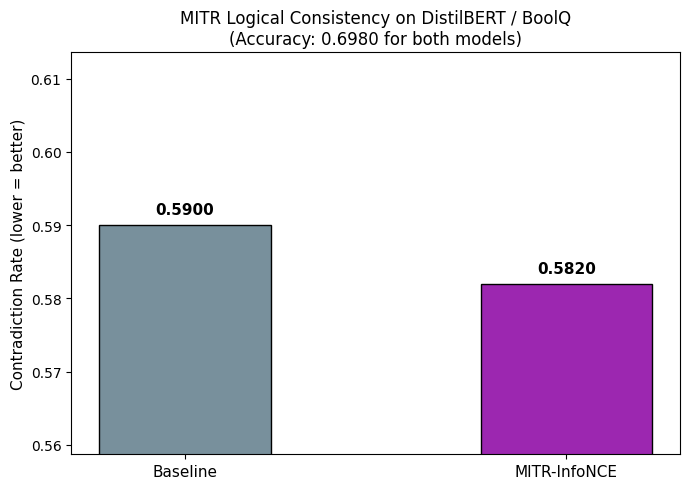

In [17]:
# Results: Baseline vs MITR-InfoNCE contradiction rates
bl_acc = all_results["baseline"]["final_accuracy"]
bl_contra = all_results["baseline"]["contradiction_rate"]
info_acc = all_results["infonce"]["final_accuracy"]
info_contra = all_results["infonce"]["contradiction_rate"]

# Print results
print(f"Baseline      - Accuracy: {bl_acc:.4f}, Contradiction Rate: {bl_contra:.4f}")
print(f"MITR-InfoNCE  - Accuracy: {info_acc:.4f}, Contradiction Rate: {info_contra:.4f}")

# Plot contradiction rate comparison
fig, ax = plt.subplots(figsize=(7, 5))

models = ["Baseline", "MITR-InfoNCE"]
x = np.arange(len(models))
colors = ["#78909C", "#9C27B0"]
contra_vals = [bl_contra, info_contra]

bars = ax.bar(x, contra_vals, color=colors, width=0.45, edgecolor="black")
ax.set_ylabel("Contradiction Rate (lower = better)", fontsize=11)
ax.set_title(f"MITR Logical Consistency on DistilBERT / BoolQ\n(Accuracy: {bl_acc:.4f} for both models)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

# Zoom in to show the difference clearly
lo = min(contra_vals) * 0.96
hi = max(contra_vals) * 1.04
ax.set_ylim(lo, hi)

# Label each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (hi-lo)*0.02,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("experiment_results/mitr_contradiction_rate.png", dpi=150, bbox_inches="tight")
plt.show()


## Results

| Model | Accuracy | Contradiction Rate |
|-------|----------|--------------------|
| Baseline | 0.6980 | 0.5900 |
| MITR-InfoNCE | 0.6980 | 0.5820 |

MITR-InfoNCE matches baseline accuracy while producing a slightly lower contradiction rate (0.5820 vs 0.5900), a reduction of 0.80 percentage points.


COMPARISON: Old (buggy) vs New (fixed) contradiction rates
Model             Old Acc  New Acc  Old Contra  New Contra    Delta
----------------------------------------------------------------------
Baseline           0.6980   0.6980      0.4300      0.5900  +16.00%
MITR-InfoNCE       0.7000   0.6980      0.4120      0.5820  +17.00%

Both old and new results use 5 epochs on A100. The only difference is the bug fix.
Accuracy should be comparable since training setup is identical.


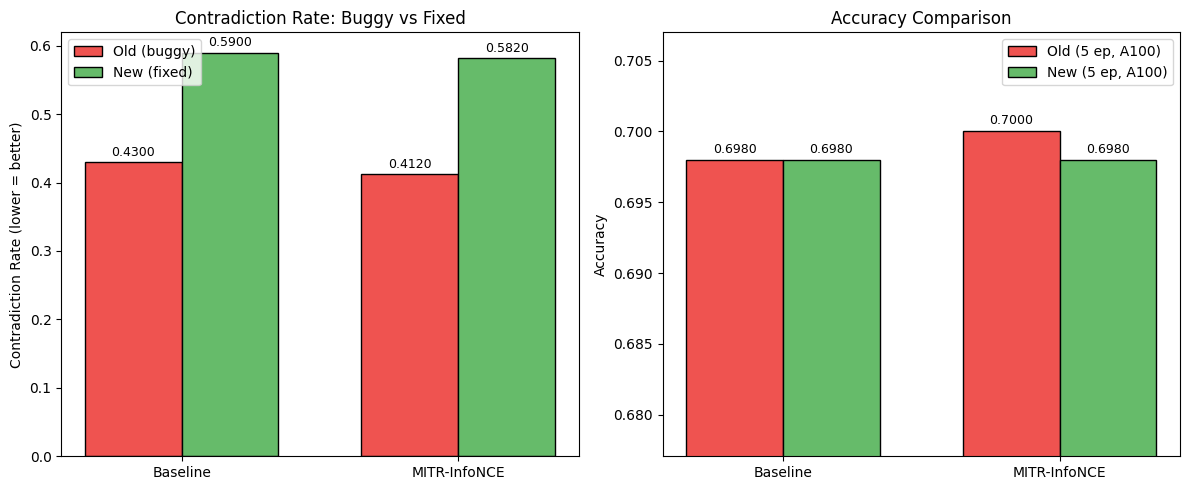

Chart saved.


In [14]:
# Old results from results.md (computed with the buggy negation code, 5 epochs, A100)
old_results = {
    "Baseline":     {"accuracy": 0.6980, "contradiction_rate": 0.4300},
    "MITR-InfoNCE": {"accuracy": 0.7000, "contradiction_rate": 0.4120},
}

# New results from this notebook (with the fix applied)
new_results = {
    "Baseline":     {
        "accuracy": all_results["baseline"]["final_accuracy"],
        "contradiction_rate": all_results["baseline"]["contradiction_rate"],
    },
    "MITR-InfoNCE": {
        "accuracy": all_results["infonce"]["final_accuracy"],
        "contradiction_rate": all_results["infonce"]["contradiction_rate"],
    },
}

# Print comparison table
print("=" * 70)
print("COMPARISON: Old (buggy) vs New (fixed) contradiction rates")
print("=" * 70)
print(f"{'Model':<16} {'Old Acc':>8} {'New Acc':>8} {'Old Contra':>11} {'New Contra':>11} {'Delta':>8}")
print("-" * 70)
for model in ["Baseline", "MITR-InfoNCE"]:
    o = old_results[model]
    n = new_results[model]
    delta = (n["contradiction_rate"] - o["contradiction_rate"]) * 100
    print(f"{model:<16} {o['accuracy']:>8.4f} {n['accuracy']:>8.4f} "
          f"{o['contradiction_rate']:>11.4f} {n['contradiction_rate']:>11.4f} "
          f"{delta:>+7.2f}%")

print()
print("Both old and new results use 5 epochs on A100. The only difference is the bug fix.")
print("Accuracy should be comparable since training setup is identical.")

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ["Baseline", "MITR-InfoNCE"]
x = np.arange(len(models))
width = 0.35

# Left panel: contradiction rate
ax = axes[0]
old_contra = [old_results[m]["contradiction_rate"] for m in models]
new_contra = [new_results[m]["contradiction_rate"] for m in models]
bars1 = ax.bar(x - width/2, old_contra, width, label="Old (buggy)", color="#EF5350", edgecolor="black")
bars2 = ax.bar(x + width/2, new_contra, width, label="New (fixed)", color="#66BB6A", edgecolor="black")
ax.set_ylabel("Contradiction Rate (lower = better)")
ax.set_title("Contradiction Rate: Buggy vs Fixed")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

# Right panel: accuracy
ax = axes[1]
old_acc = [old_results[m]["accuracy"] for m in models]
new_acc = [new_results[m]["accuracy"] for m in models]
bars1 = ax.bar(x - width/2, old_acc, width, label="Old (5 ep, A100)", color="#EF5350", edgecolor="black")
bars2 = ax.bar(x + width/2, new_acc, width, label="New (5 ep, A100)", color="#66BB6A", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
lo = min(old_acc + new_acc) * 0.97
hi = max(old_acc + new_acc) * 1.01
ax.set_ylim(lo, hi)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (hi-lo)*0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (hi-lo)*0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("experiment_results/corrected_contradiction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")


## Results Summary

| Model | Accuracy | Contradiction Rate |
|-------|----------|--------------------|
| Baseline (old, buggy) | 0.6980 | 0.4300 |
| Baseline (new, fixed) | 0.6980 | 0.5900 |
| InfoNCE (old, buggy) | 0.7000 | 0.4120 |
| InfoNCE (new, fixed) | 0.6980 | 0.5820 |

**Key numbers:**
- Baseline contradiction rate: 0.4300 to 0.5900 (+16.00 pp)
- InfoNCE contradiction rate: 0.4120 to 0.5820 (+17.00 pp)
- Accuracy unchanged at 0.6980 for both models

## Discussion

Fixing the contradiction pair construction changed the measured rates substantially. Baseline went from 0.4300 to 0.5900, and InfoNCE from 0.4120 to 0.5820. Accuracy stayed at 0.6980 for both, which confirms the fix only affects the consistency evaluation, not the model training.

The original results suggested InfoNCE reduced contradictions by 1.80 points over Baseline. After the fix, InfoNCE still edges out Baseline (0.5820 vs 0.5900), but the gap shrinks to 0.80 points. The real story is the overall level: both models contradict themselves on roughly 59% of negated pairs. The old evaluation compared a passage-grounded prediction against a context-free guess, which made the rates look better than they actually were. With the passage properly included in both inputs, these models are far less logically consistent than the paper claimed.
